In [1]:
import pandas as pd
import plotnine

from paths import val_set_csv_metadata, test_set_csv_metadata

plot_save_folder = "data_exploration_plots"
# create folder if it doesn't exist
import os
os.makedirs(plot_save_folder, exist_ok=True)

df_val = pd.read_csv(val_set_csv_metadata)

df_test_merged = pd.read_csv(test_set_csv_metadata)

q1 = "Q1: Credibility assessment presence"
q2 = "Q2: Credibility assessment sentiment"
conf_q1 = "Confidence Q1"
conf_q2 = "Confidence Q2"

df_val.head()
df_test_merged.head()


,Text/Decision,Year,link,archive_link,CASE OUTCOME,Q1: Credibility assessment presence (H1),Confidence Q1 (H1),Q1: Credibility assessment presence (H2),Confidence Q1 (H2),Q1: Credibility assessment presence (H3),Q2: Credibility assessment sentiment (H1),Confidence Q2 (H1),Q2: Credibility assessment sentiment (H2),Confidence Q2 (H2),Q2: Credibility assessment sentiment (H3),Index
0,Nævnet omgjorde i april 2023 Udlændingestyrels...,2023,https://fln.dk/praksis/2023/maj/29b-graek20233/,https://web.archive.org/web/20260228212808/htt...,rejection_reversed,N,HIGH,N,HIGH,NaN,-,-,-,-,NaN,-1.0
1,Nævnet stadfæstede i maj 2025 Udlændingestyrel...,2025,https://fln.dk/praksis/2025/maj/arme20255/,https://web.archive.org/web/20260303200243/htt...,rejection_upheld,Y,HIGH,Y,HIGH,NaN,NEGATIVE,HIGH,NEGATIVE,HIGH,NaN,-1.0
2,Nævnet stadfæstede i juli 2025 Udlændingestyre...,2025,https://fln.dk/praksis/2025/juni/dub-tysk202518/,https://web.archive.org/web/20260303200553/htt...,rejection_upheld,N,HIGH,N,HIGH,NaN,-,-,-,-,NaN,-1.0
3,Nævnet stadfæstede i juli 2025 Udlændingestyre...,2025,https://fln.dk/praksis/2025/juli/dub-tysk202519/,https://web.archive.org/web/20260303200703/htt...,rejection_upheld,N,MEDIUM,N,HIGH,NaN,-,-,-,-,NaN,-1.0
4,Nævnet stadfæstede i maj og 2025 Udlændingesty...,2025,https://fln.dk/praksis/2025/maj/29b-tysk20253/,https://web.archive.org/web/20260303211724/htt...,rejection_upheld,N,HIGH,N,HIGH,NaN,-,-,-,-,NaN,-1.0


Validation set: min=174, avg=530.0958904109589, max=1158
Validation set: min=11, avg=28.273972602739725, max=57
Test set: min=178, avg=648.53, max=1789
Test set: min=9, avg=34.385, max=94
|       |   num_words |
|:------|------------:|
| count |     273     |
| mean  |     616.861 |
| std   |     286.749 |
| min   |     174     |
| 25%   |     414     |
| 50%   |     553     |
| 75%   |     768     |
| max   |    1789     |
|       |   num_sentences |
|:------|----------------:|
| count |        273      |
| mean  |         32.7509 |
| std   |         13.8044 |
| min   |          9      |
| 25%   |         24      |
| 50%   |         31      |
| 75%   |         38      |
| max   |         94      |


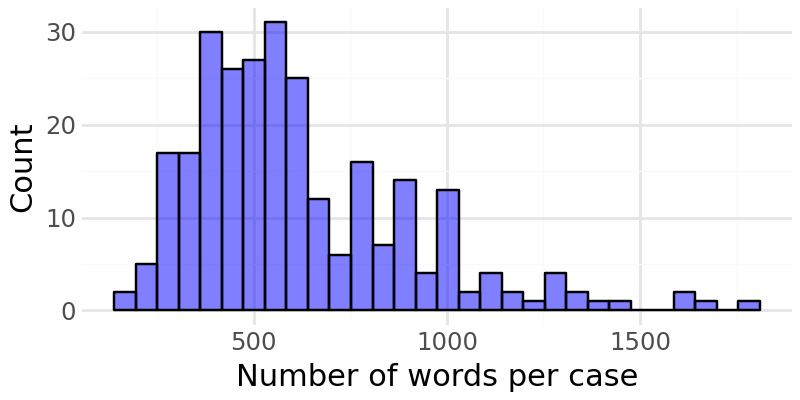

/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 4 x 2 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: data_exploration_plots/num_words_histogram.pdf


Sample with longest Text/Decision in validation set:
16636.0
Sample with shortest Text/Decision in validation set:
6303.0


/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 4 x 2 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: data_exploration_plots/num_words_histogram.png


In [2]:
# min, avg and max num of words in val and test set, looking at column Text/Decision

num_words = df_val["Text/Decision"].apply(lambda x: len(str(x).split()))
num_sentences = df_val["Text/Decision"].apply(lambda x: len(str(x).split(".")))
print(f"Validation set: min={num_words.min()}, avg={num_words.mean()}, max={num_words.max()}")
print(f"Validation set: min={num_sentences.min()}, avg={num_sentences.mean()}, max={num_sentences.max()}")
num_words_test = df_test_merged["Text/Decision"].apply(lambda x: len(str(x).split()))
num_sentences_test = df_test_merged["Text/Decision"].apply(lambda x: len(str(x).split(".")))
print(f"Test set: min={num_words_test.min()}, avg={num_words_test.mean()}, max={num_words_test.max()}")
print(f"Test set: min={num_sentences_test.min()}, avg={num_sentences_test.mean()}, max={num_sentences_test.max()}")

# combine dataframes for val and test set, adding a column to indicate which set they belong to
df_val["Set"] = "Validation"
df_test_merged["Set"] = "Test"
df_combined = pd.concat([df_val, df_test_merged], ignore_index=True)
assert len(df_combined) == len(df_val) + len(df_test_merged) == 273
num_words_combined = df_combined["Text/Decision"].apply(lambda x: len(str(x).split()))
df_combined["num_words"] = num_words_combined
df_combined["num_sentences"] = df_combined["Text/Decision"].apply(lambda x: len(str(x).split(".")))

print(df_combined[["num_words"]].describe().to_markdown())
print(df_combined[["num_sentences"]].describe().to_markdown())

# make a histogram of the distribution of number of words in the Text/Decision column for both val and test set
plt = (plotnine.ggplot(df_combined, plotnine.aes(x="num_words"))
       + plotnine.geom_histogram(position="identity", alpha=0.5, bins=30, fill="blue", color="black")
       #+ plotnine.ggtitle("Number of words per case in the RAB-Cred dataset")
       + plotnine.xlab("Number of words per case")
       + plotnine.ylab("Count")
       + plotnine.theme_minimal()
       + plotnine.theme(figure_size=(4, 2))
      )
plt.show()
plt.save(f"{plot_save_folder}/num_words_histogram.pdf", dpi=300)
plt.save(f"{plot_save_folder}/num_words_histogram.png", dpi=300)

# find sample in val set with the longest Text/Decision and print it
longest_sample = df_val.loc[num_words.idxmax()]
print("Sample with longest Text/Decision in validation set:")
print(longest_sample["Index"])

# find shortest sample in val set and print it
shortest_sample = df_val.loc[num_words.idxmin()]
print("Sample with shortest Text/Decision in validation set:")
print(shortest_sample["Index"])

In [3]:
# compute disagreement from the merged dataframe
num_disagreements = dict()
for question in [q1, q2]:
    num_disagreements[question] = 0
    if not df_test_merged[f"{question} (H1)"].equals(df_test_merged[f"{question} (H2)"]):
        # iterate through both and print the differing rows
        for i in range(len(df_test_merged)):
            if str(df_test_merged[f"{question} (H1)"].iloc[i]).lower() != str(df_test_merged[f"{question} (H2)"].iloc[i]).lower():
                print(f"Row (Index {df_test_merged['Index'].iloc[i]}) differs when looking at '{question}':")
                print(f"df_test (H1): {df_test_merged[f'{question} (H1)'].iloc[i]} (confidence: {df_test_merged[f'Confidence Q1 (H1)'].iloc[i] if question == q1 else df_test_merged[f'Confidence Q2 (H1)'].iloc[i]})")
                print(f"df_test (H2): {df_test_merged[f'{question} (H2)'].iloc[i]} (confidence: {df_test_merged[f'Confidence Q1 (H2)'].iloc[i] if question == q1 else df_test_merged[f'Confidence Q2 (H2)'].iloc[i]})\n")
                num_disagreements[question] += 1
    print(f"Total number of disagreements for '{question}' from merged dataframe: {num_disagreements[question]}")
    print(f"\n----------------------------------\n")

# kappa coefficient calculation for both questions from merged dataframe
from sklearn.metrics import cohen_kappa_score

chosen_class_M = df_test_merged.apply(lambda row: "Absent" if row[q1 + ' (H1)'] == 'N' else row[q2 + ' (H1)'], axis=1)
chosen_class_A = df_test_merged.apply(lambda row: "Absent" if row[q1 + ' (H2)'] == 'N' else row[q2 + ' (H2)'], axis=1)
cohen_kappa_score(chosen_class_M, chosen_class_A)
print(f"Cohen's Kappa for combined chosen class from merged dataframe: {cohen_kappa_score(chosen_class_M, chosen_class_A)}\n")

for question in [q1, q2]:
    print(df_test_merged[f"{question} (H2)"].unique())
    kappa = cohen_kappa_score(df_test_merged[f"{question} (H1)"], df_test_merged[f"{question} (H2)"])
    
    print(f"Cohen's Kappa for '{question}' from merged dataframe: {kappa}\n")

Row (Index 1329.0) differs when looking at 'Q1: Credibility assessment presence':
df_test (H1): N (confidence: LOW)
df_test (H2): Y (confidence: MEDIUM)

Row (Index 7130.0) differs when looking at 'Q1: Credibility assessment presence':
df_test (H1): Y (confidence: HIGH)
df_test (H2): N (confidence: HIGH)

Total number of disagreements for 'Q1: Credibility assessment presence' from merged dataframe: 2

----------------------------------

Row (Index 1262.0) differs when looking at 'Q2: Credibility assessment sentiment':
df_test (H1): POSITIVE (confidence: HIGH)
df_test (H2): NEGATIVE (confidence: HIGH)

Row (Index 1329.0) differs when looking at 'Q2: Credibility assessment sentiment':
df_test (H1): - (confidence: -)
df_test (H2): NEGATIVE (confidence: HIGH)

Row (Index 7130.0) differs when looking at 'Q2: Credibility assessment sentiment':
df_test (H1): POSITIVE (confidence: HIGH)
df_test (H2): - (confidence: -)

Row (Index 7887.0) differs when looking at 'Q2: Credibility assessment sent

[[41  0  1]
 [ 1 62  2]
 [ 0  0 93]]


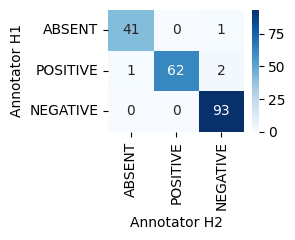

In [4]:
# make a confusion matrix for question 2 by both annotators from the merged dataframe
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(df_test_merged[f"{q2} (H1)"], df_test_merged[f"{q2} (H2)"], labels=["-", "POSITIVE","NEGATIVE"])
print(conf_matrix)
plt.figure(figsize=(3, 2.5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["ABSENT", "POSITIVE","NEGATIVE"], yticklabels=["ABSENT", "POSITIVE","NEGATIVE"])
plt.xlabel("Annotator H2")
plt.ylabel("Annotator H1")
plt.tight_layout()
# bigger text inside the plot
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
#plt.title("Credibility Assessment")

plt.savefig(f"{plot_save_folder}/confusion_matrix_annotators.pdf", dpi=300)
plt.savefig(f"{plot_save_folder}/confusion_matrix_annotators.png", dpi=300)
plt.show()

|    | Annotators                           | Credibility Assessment   |
|---:|:-------------------------------------|:-------------------------|
|  0 | Q2: Credibility assessment sentiment | -                        |
|  1 | Q2: Credibility assessment sentiment | POSITIVE                 |
|  2 | Q2: Credibility assessment sentiment | -                        |
|  3 | Q2: Credibility assessment sentiment | -                        |
|  4 | Q2: Credibility assessment sentiment | -                        |
<ggplot: (500 x 108)>


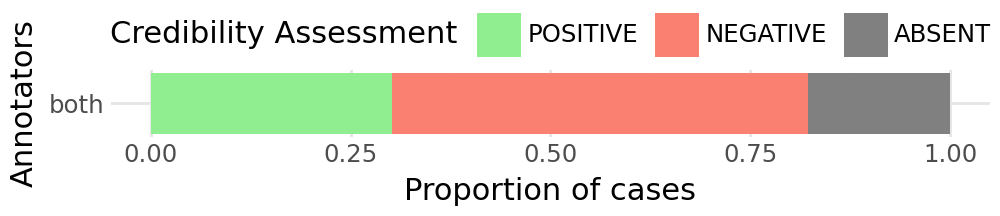

/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 5 x 1.08 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: data_exploration_plots/val_set_label_distribution.pdf
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 5 x 1.08 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: data_exploration_plots/val_set_label_distribution.png


|    | Question      | Confidence   |
|---:|:--------------|:-------------|
|  0 | Confidence Q1 | HIGH         |
|  1 | Confidence Q1 | HIGH         |
|  2 | Confidence Q1 | HIGH         |
|  3 | Confidence Q1 | HIGH         |
|  4 | Confidence Q1 | MEDIUM       |
<ggplot: (500 x 140)>


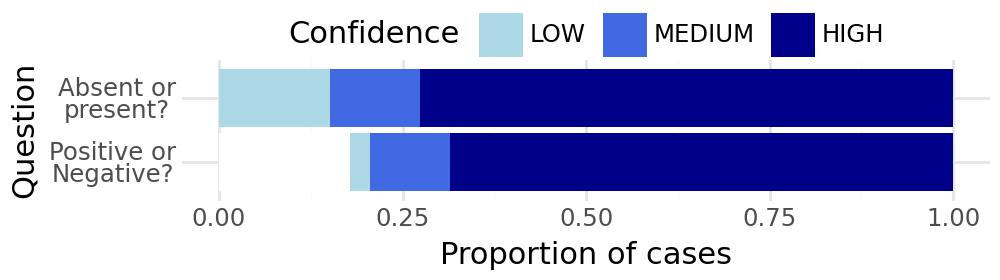

/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 5 x 1.4 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: data_exploration_plots/val_set_confidence_distribution.pdf
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 5 x 1.4 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: data_exploration_plots/val_set_confidence_distribution.png


In [5]:
import plotnine

# make a stacked bar plot of the distribution of credibility labels for both questions in the merged test set
for question in [q2]:
    df_plot = df_val[[f"{question}"]].melt(var_name='Annotators', value_name='Credibility Assessment')
    print(df_plot.head().to_markdown())
    df_plot['Annotators'] = "both"
    df_plot['Credibility Assessment'] = df_plot['Credibility Assessment'].replace({"-": "ABSENT"})
    p = (plotnine.ggplot(df_plot, plotnine.aes(x='Annotators', fill='Credibility Assessment'))
         + plotnine.geom_bar(position='fill')
         + plotnine.scale_fill_manual(values={"POSITIVE": "lightgreen", "NEGATIVE": "salmon", "ABSENT": "grey"}, limits=["POSITIVE", "NEGATIVE", "ABSENT"])
         #+ plotnine.ggtitle(f'Validation set label distribution')
         + plotnine.ylab('Proportion of cases')
         # flip the x and y axis
         + plotnine.coord_flip()
         + plotnine.theme_minimal()
         + plotnine.theme(figure_size=(5, 1.08), legend_position="top")
         + plotnine.theme(legend_box_spacing=0.01)
        )
    print(p)
    p.show()
    p.save(f"{plot_save_folder}/val_set_label_distribution.pdf", dpi=300)
    p.save(f"{plot_save_folder}/val_set_label_distribution.png", dpi=300)
    
df_plot = df_val[[conf_q1, conf_q2]].melt(var_name='Question', value_name='Confidence')
print(df_plot.head().to_markdown())
#df_plot['Annotators'] = "both"
df_plot['Question'] = df_plot['Question'].replace({conf_q1: "Absent or\npresent?", conf_q2: "Positive or\nNegative?"})
df_plot['Question'] = pd.Categorical(df_plot['Question'], categories=["Positive or\nNegative?", "Absent or\npresent?"], ordered=True)
df_plot['Confidence'] = df_plot['Confidence'].replace({"-": ""})
df_plot['Confidence'] = pd.Categorical(df_plot['Confidence'], categories=["HIGH", "MEDIUM", "LOW", ""], ordered=True)
p = (plotnine.ggplot(df_plot, plotnine.aes(x='Question', fill='Confidence'))
        + plotnine.geom_bar(position='fill')
        + plotnine.scale_fill_manual(values={ "LOW": "lightblue", "": "white",  "MEDIUM": "royalblue", "HIGH": "darkblue"}, limits=["LOW", "MEDIUM", "HIGH"])

        + plotnine.ylab('Proportion of cases')
        # margin between legend and plot
        + plotnine.coord_flip()
        + plotnine.theme_minimal()
        # change legend order
        + plotnine.theme(figure_size=(5, 1.4), legend_position="top")
        + plotnine.theme(legend_box_spacing=0)
    )
print(p)
p.show()
p.save(f"{plot_save_folder}/val_set_confidence_distribution.pdf", dpi=300)

p.save(f"{plot_save_folder}/val_set_confidence_distribution.png", dpi=300)

<ggplot: (900 x 250)>


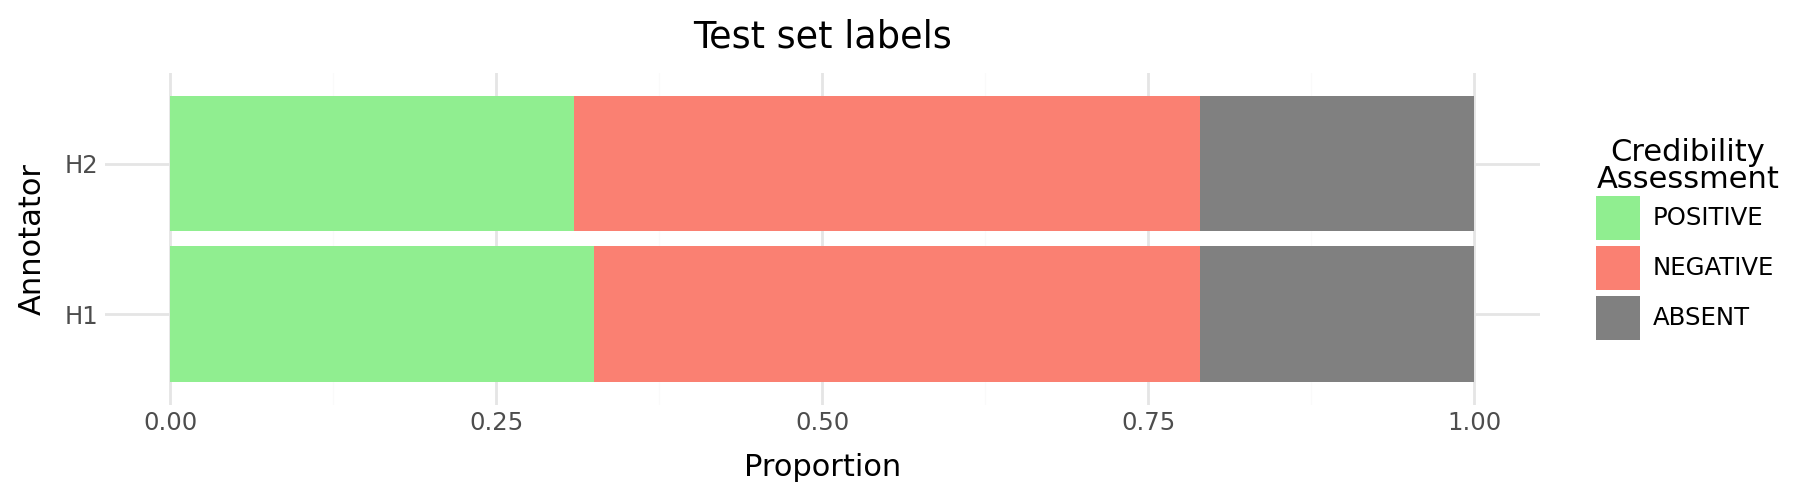

/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 9 x 2.5 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: data_exploration_plots/test_set_labels.pdf


<ggplot: (900 x 250)>


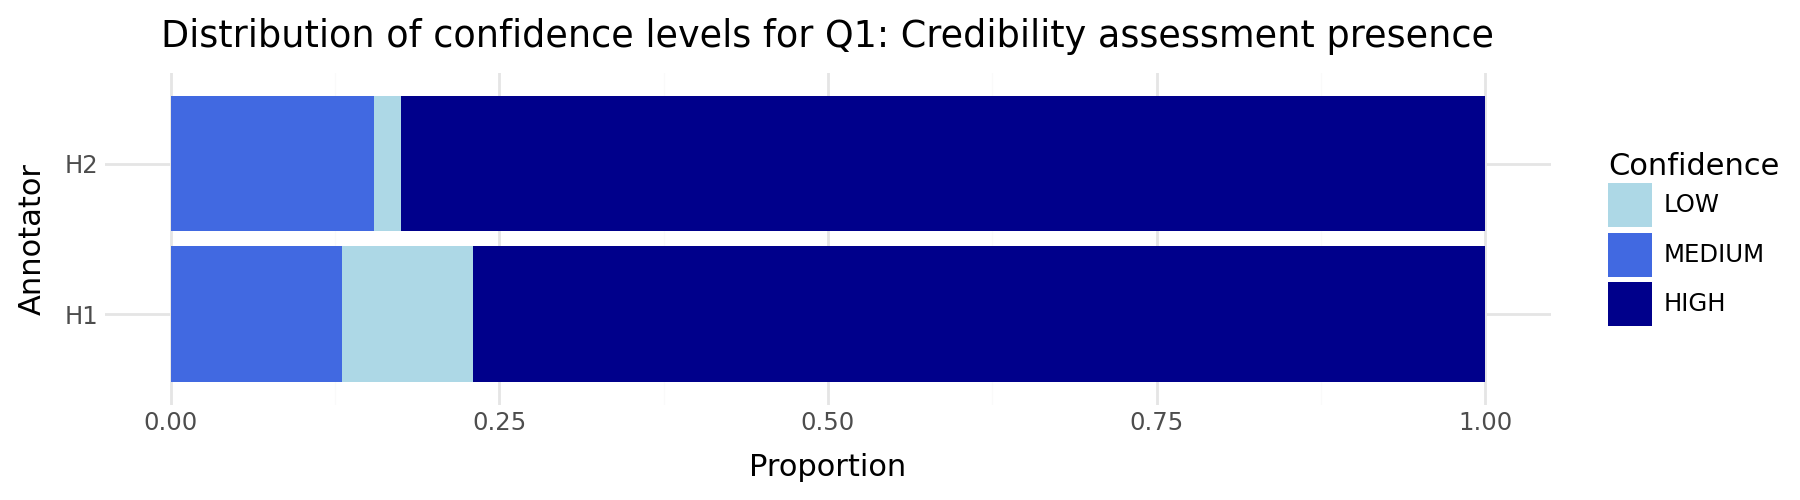

/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 9 x 2.5 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: data_exploration_plots/test_set_confidence_levels_Q1:_Credibility_assessment_presence.pdf


<ggplot: (900 x 250)>


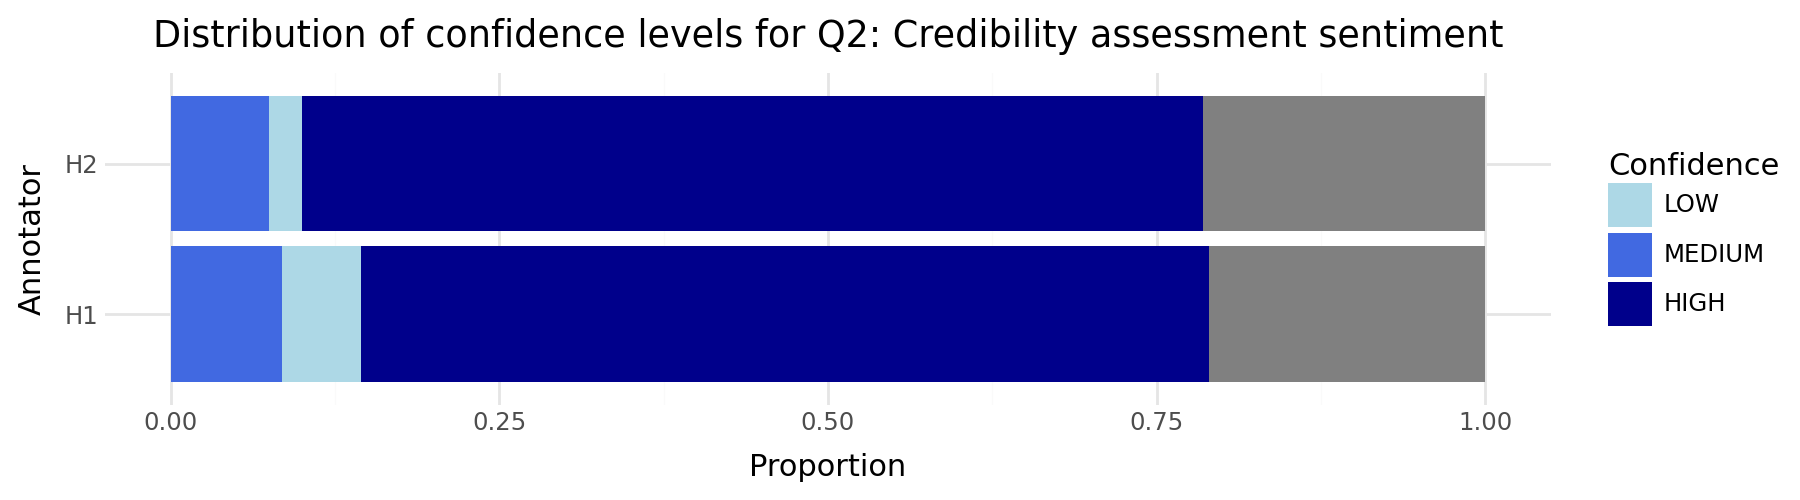

/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 9 x 2.5 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: data_exploration_plots/test_set_confidence_levels_Q2:_Credibility_assessment_sentiment.pdf


In [6]:
# make a stacked bar plot of the distribution of credibility labels for both questions in the merged test set
for question in [q2]:
    df_plot = df_test_merged[[f"{question} (H1)", f"{question} (H2)"]].melt(var_name='Annotator', value_name='Credibility Assessment')
    df_plot['Credibility Assessment'] = df_plot['Credibility Assessment'].replace({"-": "ABSENT"})
    df_plot['Annotator'] = df_plot['Annotator'].replace({f"{question} (H1)": "H1", f"{question} (H2)": "H2"})
    p = (plotnine.ggplot(df_plot, plotnine.aes(x='Annotator', fill='Credibility Assessment'))
         + plotnine.geom_bar(position='fill')
         + plotnine.coord_flip()
         + plotnine.scale_fill_manual(values={"POSITIVE": "lightgreen", "NEGATIVE": "salmon", "ABSENT": "grey"}, limits=["POSITIVE", "NEGATIVE", "ABSENT"], guide=plotnine.guide_legend(title='Credibility\nAssessment'))
         + plotnine.ggtitle(f'Test set labels')
         + plotnine.ylab('Proportion')
         + plotnine.theme_minimal()
         + plotnine.theme(figure_size=(9,2.5))
         
        )
    print(p)
    p.show()
    p.save(f"{plot_save_folder}/test_set_labels.pdf")
    
# make a stacked bar plot of the distribution of confidence levels for both questions in the merged test set
for question, conf_col in [(q1, conf_q1), (q2, conf_q2)]:
    df_plot = df_test_merged[[f"{conf_col} (H1)", f"{conf_col} (H2)"]].melt(var_name='Annotator', value_name='Confidence')
    df_plot["Annotator"] = df_plot["Annotator"].apply(lambda x: "H1" if " (H1)" in x else "H2")
    p = (plotnine.ggplot(df_plot, plotnine.aes(x='Annotator', fill='Confidence'))
         + plotnine.geom_bar(position='fill')
         + plotnine.scale_fill_manual(values={ "LOW": "lightblue", "": "white",  "MEDIUM": "royalblue", "HIGH": "darkblue","-": "grey"}, limits=["LOW", "MEDIUM", "HIGH","-"] if "Question 2" in question else ["LOW", "MEDIUM", "HIGH"])
         + plotnine.coord_flip()
         + plotnine.ggtitle(f'Distribution of confidence levels for {question}')
         + plotnine.ylab('Proportion')
         + plotnine.theme_minimal()
         + plotnine.theme(figure_size=(9,2.5))
        )
    print(p)
    p.show()
    p.save(f"{plot_save_folder}/test_set_confidence_levels_{question.replace(' ', '_')}.pdf")



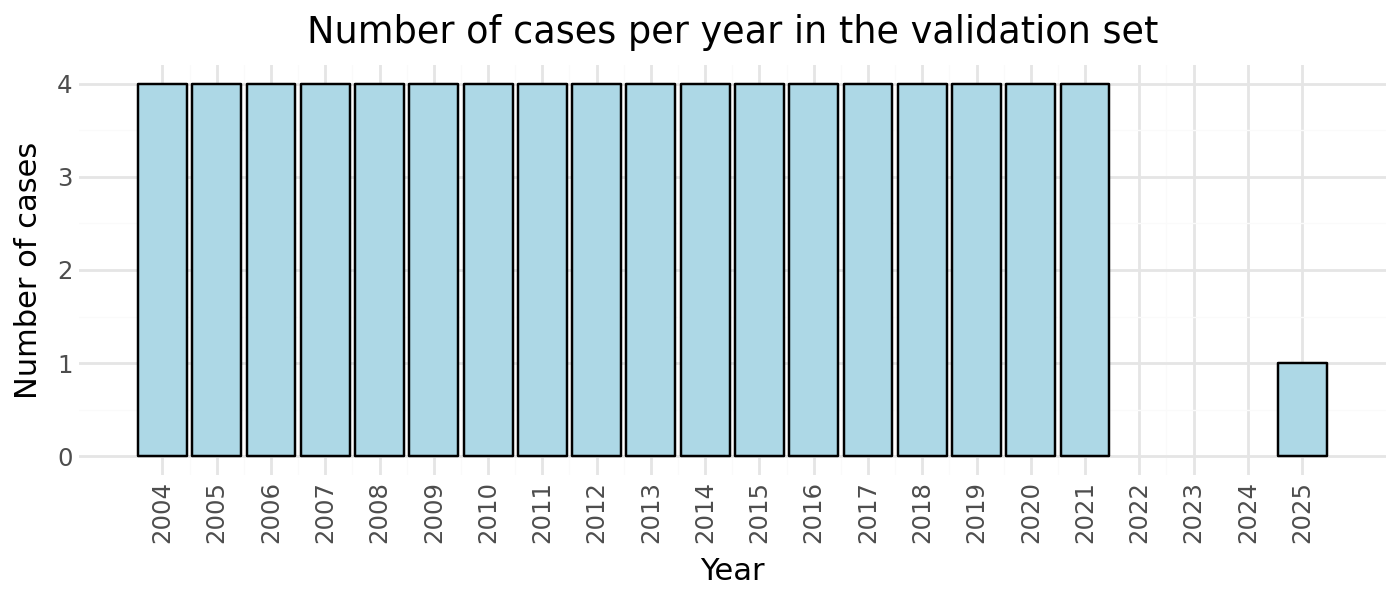

/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 7 x 3 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: data_exploration_plots/num_cases_per_year_val_set.pdf


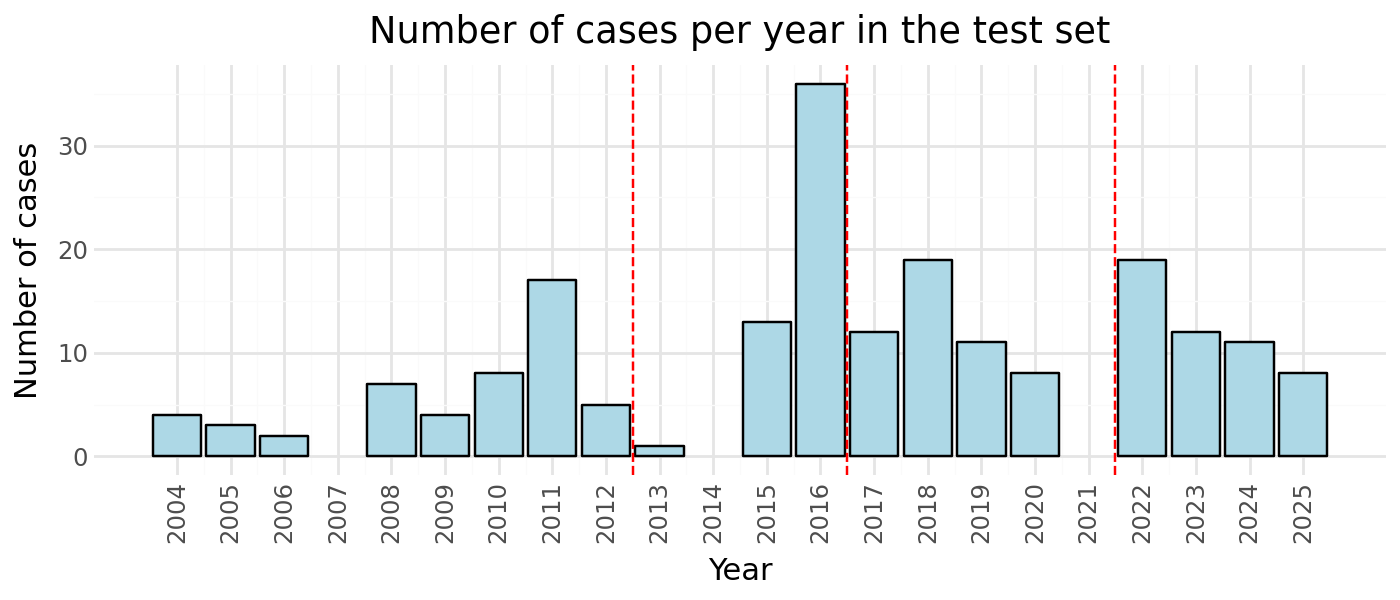

/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 7 x 3 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: data_exploration_plots/num_cases_per_year_test_set.pdf


In [7]:
# plot the number of cases per year for the val and the test set

p_val = (plotnine.ggplot(df_val, plotnine.aes(x='Year'))
         + plotnine.geom_bar(fill='lightblue', color='black')
         + plotnine.ggtitle('Number of cases per year in the validation set')
         + plotnine.scale_x_continuous(breaks=df_combined["Year"].unique())
         + plotnine.xlab('Year')
         + plotnine.ylab('Number of cases')
         + plotnine.theme_minimal()
         + plotnine.theme(axis_text_x=plotnine.element_text(rotation=90, hjust=0.5))
         + plotnine.theme(figure_size=(7, 3))
        )
p_val.show()
p_val.save(f"{plot_save_folder}/num_cases_per_year_val_set.pdf", dpi=300)

p_val = (plotnine.ggplot(df_test_merged, plotnine.aes(x='Year'))
         + plotnine.geom_bar(fill='lightblue', color='black')
         + plotnine.ggtitle('Number of cases per year in the test set')
         + plotnine.scale_x_continuous(breaks=df_combined["Year"].unique())
         + plotnine.xlab('Year')
         + plotnine.ylab('Number of cases')
         + plotnine.geom_vline(xintercept=[2012.5, 2016.5, 2021.5], linetype="dashed", color="red")
         + plotnine.theme_minimal()
         + plotnine.theme(axis_text_x=plotnine.element_text(rotation=90, hjust=0.5))
         + plotnine.theme(figure_size=(7, 3))
        )
p_val.show()
p_val.save(f"{plot_save_folder}/num_cases_per_year_test_set.pdf", dpi=300)

case_texts = df_combined[["Text/Decision"]]
assert len(case_texts) == 273
import re

num_redacted_per_year = dict()
for year in df_combined["Year"].unique():
    num_redacted_per_year[year] = 0
    for text in df_combined[df_combined["Year"] == year]["Text/Decision"]:
        redacted_portions = re.findall(r"\[.*?\]", text)
        num_redacted_per_year[year] += len(redacted_portions)
    num_redacted_per_year[year] /= len(df_combined[df_combined["Year"] == year])
    

/tmp/ipykernel_1599795/2290956886.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_1599795/2290956886.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_1599795/2290956886.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykerne

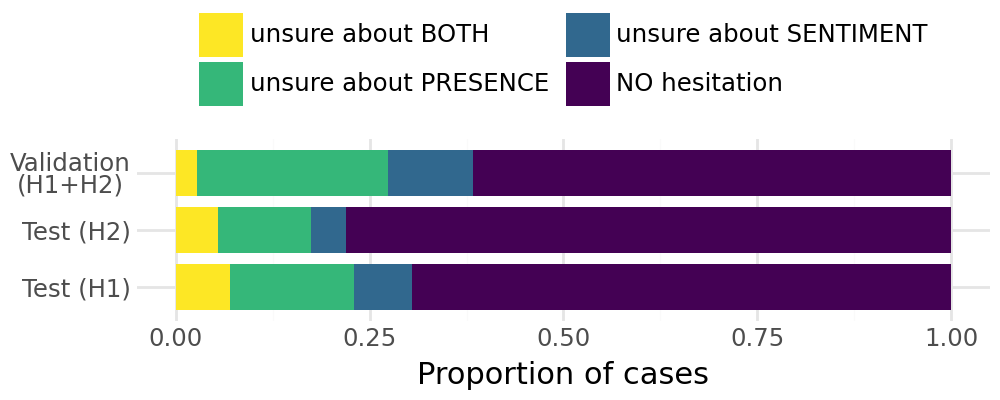

/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 5 x 2 in image.
/home/gala/PROJECTS/RAB-Cred/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: data_exploration_plots/hesitation_types_combined.pdf


In [8]:
def categorize_confusion_type(row, suffix=""):
    conf_q1_row = row[conf_q1+suffix]
    conf_q2_row = row[conf_q2+suffix]
    q1_row = row[q1+suffix]
    q2_row = row[q2+suffix]
    #print(f"Row {row['Index']} - conf_q1_row: {conf_q1_row}, conf_q2_row: {conf_q2_row}, q1_row: {q1_row}, q2_row: {q2_row}")
    if conf_q1_row == conf_q2_row == "HIGH" or (conf_q1_row == "HIGH" and conf_q2_row == "-"):
        return "NO hesitation"
    elif conf_q1_row == "HIGH" and conf_q2_row != "-":
        return "unsure about SENTIMENT"
    elif conf_q1_row != "HIGH" and conf_q2_row not in ["HIGH","-"]:
        return "unsure about BOTH"
    elif conf_q1_row != "HIGH":
        return "unsure about PRESENCE"
    
    else:
        print(f"Unexpected case in row {row['Index']}: conf_q1_row={conf_q1_row}, conf_q2_row={conf_q2_row}")

df_A = df_test_merged[[c for c in df_test_merged.columns if c.endswith("(H2)") or c in ["Index"]]]
df_M = df_test_merged[[c for c in df_test_merged.columns if c.endswith("(H1)") or c in ["Index"]]]
df_val["hesitation"] = df_val.apply(lambda row: categorize_confusion_type(row), axis=1)
df_val["set"] = "Validation\n(H1+H2)"
df_val.groupby("hesitation").count()

df_A["hesitation"] = df_A.apply(lambda row: categorize_confusion_type(row, suffix=" (H2)"), axis=1)
df_A["set"] = "Test (H2)"
df_A.groupby("hesitation").count()

df_M["hesitation"] = df_M.apply(lambda row: categorize_confusion_type(row, suffix=" (H1)"), axis=1)
df_M["set"] = "Test (H1)"
df_M.groupby("hesitation").count()

df_hesitation_combined = pd.concat([df_val, df_A, df_M])
# order the hesitation categories
df_hesitation_combined["hesitation"] = pd.Categorical(df_hesitation_combined["hesitation"], categories=["NO hesitation", "unsure about SENTIMENT", "unsure about PRESENCE", "unsure about BOTH"], ordered=True)

# create a stacked bar plot from hesitation column in df_A, showing the distribution of the different types of hesitation
plt = (plotnine.ggplot(df_hesitation_combined, plotnine.aes(x="set", fill="hesitation"))
       + plotnine.geom_bar(position="fill", width=0.8)

       + plotnine.xlab("")
       + plotnine.ylab("Proportion of cases")
       + plotnine.theme_minimal()
       # hide legend title
       + plotnine.theme(legend_title=plotnine.element_blank())
       + plotnine.coord_flip()
       + plotnine.guides(fill=plotnine.guide_legend(ncol=3, position="top", reverse=True))
       + plotnine.theme(figure_size=(5, 2))
      )
plt.show()
plt.save(f"{plot_save_folder}/hesitation_types_combined.pdf")
